In [ ]:
import zarr
import re
import os
import gc
import time

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import dask.array as da

from tqdm.notebook import tqdm
from dask.diagnostics import ProgressBar
from sklearn.model_selection import train_test_split

In [2]:
def sanitize_key(key):
    return re.sub(r'[^\w]', '_', str(key)).strip('_')

**Choose HVGs**

In [3]:
adata = sc.read_h5ad('/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/rpe1_essential/rpe1_normalized_singlecell_01.h5ad')
adata

AnnData object with n_obs × n_vars = 247914 × 8749
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'cell_line'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'

In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata, n_top_genes=5000)
# adata.raw = adata
# adata = adata[:, adata.var.highly_variable].copy()

In [5]:
adata

AnnData object with n_obs × n_vars = 247914 × 8749
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'cell_line'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'
    uns: 'log1p'

**Prepare combinations**

In [6]:
adata.obs['cell_id'] = adata.obs.index
adata.obs = adata.obs.reset_index(drop=True)

In [7]:
adata.obs.loc[:, 'combination_key'] = adata.obs.apply(
    lambda row: f"{sanitize_key(row['gem_group'])}-"
                f"{sanitize_key(row['gene'])}",
    axis=1
)

In [8]:
output_dir = "/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/k562_essential/comb_w_obs.zarr"

In [9]:
os.makedirs(output_dir, exist_ok=True)
n_vars = adata.X.shape[1]
root_zarr = zarr.open(output_dir, mode='a')
root_zarr.attrs['var_names'] = adata.var.index.to_list()

In [11]:
CHUNK_SIZE = 10_000
current_combinations = set()

for combination_key, group in tqdm(adata.obs.groupby('combination_key')):
    current_combinations.add(combination_key)
    x_group = adata.X[group.index]

    da.from_array(x_group, chunks=(CHUNK_SIZE, n_vars)).astype(adata.X.dtype).to_zarr(output_dir+'/'+combination_key, component='X', overwrite=True)
    da.from_array(group['cell_id'].values, chunks=-1).astype('<U40').to_zarr(output_dir+'/'+combination_key, component='obs_index', overwrite=True)

existing_combinations = set(root_zarr.attrs.get('combinations', []))
existing_combinations.update(current_combinations)
root_zarr.attrs['combinations'] = sorted(existing_combinations)

  0%|          | 0/84441 [00:00<?, ?it/s]

KeyboardInterrupt: 

**Best seed choice for split01**

In [18]:
train_ratio=0.7
val_ratio=0.15
test_ratio=0.15

for seed in range(30, 51):
    print("SEED:", seed)
    print(f"Processing combinations from {output_dir}")

    comb_dir = output_dir
    if not os.path.isdir(comb_dir):
        raise ValueError(f"Combination directory not found: {comb_dir}")

    combinations = [d for d in os.listdir(comb_dir) if not d.startswith('.')]
    cell_types = np.unique([d.split("-")[0] for d in combinations])
    print(f"Found {len(combinations)} combination directories")
    print(f"Found {len(cell_types)} cell types")

    train_val_ratio = train_ratio + val_ratio
    train_val_types, test_types = train_test_split(
        cell_types, 
        train_size=train_val_ratio,
        random_state=seed
    )

    train_types, val_types = train_test_split(
        train_val_types,
        train_size=train_ratio/train_val_ratio,
        random_state=seed
    )

    train_combs = []
    test_combs = []
    val_combs = []
    for combination in combinations:
        if combination.split("-")[0] in train_types:
            train_combs.append(combination)
        elif combination.split("-")[0] in test_types:
            test_combs.append(combination)
        elif combination.split("-")[0] in val_types:
            val_combs.append(combination)
        else:
            raise Exception(f"cell_type {combination.split('-')[0]} not found")

    print(f"Split: {len(train_combs)} train, {len(val_combs)} val, {len(test_combs)} test")

    val_arrays = []
    for comb in val_combs:
        comb_path = os.path.join(comb_dir, comb)
        val_arrays.append(da.from_zarr(comb_path, 'X'))

    val_data = da.concatenate(val_arrays, axis=0)
    print(f"Validation data shape: {val_data.shape}")

    test_arrays = []
    for comb in test_combs:
        comb_path = os.path.join(comb_dir, comb)
        test_arrays.append(da.from_zarr(comb_path, 'X'))

    test_data = da.concatenate(test_arrays,  axis=0)
    print(f"Test data shape: {test_data.shape}")
    print(f"Train data shape: ({len(adata) - test_data.shape[0] - val_data.shape[0]}, 5412)")
    print()

SEED: 30
Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Found 8 cell types
Split: 32 train, 16 val, 16 test
Validation data shape: (2783, 5000)
Test data shape: (7318, 5000)
Train data shape: (14572, 5412)

SEED: 31
Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Found 8 cell types
Split: 32 train, 16 val, 16 test


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Validation data shape: (2783, 5000)
Test data shape: (6226, 5000)
Train data shape: (15664, 5412)

SEED: 32
Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Found 8 cell types
Split: 32 train, 16 val, 16 test
Validation data shape: (12954, 5000)
Test data shape: (5829, 5000)
Train data shape: (5890, 5412)

SEED: 33
Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Found 8 cell types
Split: 32 train, 16 val, 16 test
Validation data shape: (6226, 5000)
Test data shape: (1848, 5000)
Train data shape: (16599, 5412)

SEED: 34
Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Found 8 cell types
Split: 32 train, 16 val, 16 test
Validation data shape: (661, 5000)
Test data shape: (4272, 5000)
Train data shape: (1

In [19]:
# 36, 39

**Prepare split01**

In [21]:
CHUNK_SIZE = 5_000

source_dir = '/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr'
output_dir = "/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split01"

train_ratio=0.7
val_ratio=0.15
test_ratio=0.15

seed=39

print(f"Processing combinations from {source_dir}")
os.makedirs(output_dir, exist_ok=True)

comb_dir = source_dir
if not os.path.isdir(comb_dir):
    raise ValueError(f"Combination directory not found: {comb_dir}")

combinations = [d for d in os.listdir(comb_dir) if not d.startswith('.')]
cell_types = np.unique([d.split("-")[0] for d in combinations])
print(f"Found {len(combinations)} combination directories")
print(f"Found {len(cell_types)} cell types")

train_val_ratio = train_ratio + val_ratio
train_val_types, test_types = train_test_split(
    cell_types, 
    train_size=train_val_ratio,
    random_state=seed
)

train_types, val_types = train_test_split(
    train_val_types,
    train_size=train_ratio/train_val_ratio,
    random_state=seed
)

train_combs = []
test_combs = []
val_combs = []
for combination in combinations:
    if combination.split("-")[0] in train_types:
        train_combs.append(combination)
    elif combination.split("-")[0] in test_types:
        test_combs.append(combination)
    elif combination.split("-")[0] in val_types:
        val_combs.append(combination)
    else:
        raise Exception(f"cell_type {combination.split('-')[0]} not found")

print(f"Split: {len(train_combs)} train, {len(val_combs)} val, {len(test_combs)} test")

meta_save_path = os.path.join(output_dir, "split_metadata.zarr")
meta_group = zarr.open_group(meta_save_path, mode='w')
meta_group.attrs['train_combinations'] = train_combs
meta_group.attrs['val_combinations'] = val_combs
meta_group.attrs['test_combinations'] = test_combs
meta_group.attrs['random_seed'] = seed

print("Processing validation data...")
val_arrays = []
for comb in val_combs:
    comb_path = os.path.join(comb_dir, comb)
    val_arrays.append(da.from_zarr(comb_path, 'X'))

val_data = da.concatenate(val_arrays, axis=0)
print(f"Validation data shape: {val_data.shape}")

val_save_path = os.path.join(output_dir, 'val.zarr')
print(f"Saving validation data to {val_save_path}")
with ProgressBar():
    val_data.rechunk((CHUNK_SIZE, val_data.shape[1])).to_zarr(val_save_path, component='X', overwrite=True)
print(f"Done saving validation data")

del val_arrays, val_data
gc.collect()
time.sleep(10)

print("Processing test data...")
test_arrays = []
for comb in test_combs:
    comb_path = os.path.join(comb_dir, comb)
    test_arrays.append(da.from_zarr(comb_path, 'X'))

test_data = da.concatenate(test_arrays,  axis=0)
print(f"Test data shape: {test_data.shape}")

test_save_path = os.path.join(output_dir, 'test.zarr')
print(f"Saving test data to {test_save_path}")
with ProgressBar():
    test_data.rechunk((CHUNK_SIZE, test_data.shape[1])).to_zarr(test_save_path, component='X', overwrite=True)
print(f"Done saving test data")

del test_arrays, test_data
gc.collect()
time.sleep(10)

print("Processing training data...")
train_arrays = []
for comb in train_combs:
    comb_path = os.path.join(comb_dir, comb)
    train_arrays.append(da.from_zarr(comb_path, 'X'))

train_data = da.concatenate(train_arrays, axis=0)
print(f"Training data shape: {train_data.shape}")

n_vars = train_data.shape[1]
train_data = train_data.rechunk((CHUNK_SIZE, n_vars))
print(f"Training data rechunked: {train_data.numblocks} blocks")

train_unsfd_save_path = os.path.join(output_dir, 'train_unsfd.zarr')
print(f"Saving unshuffled training data to {train_unsfd_save_path}")
with ProgressBar():
    train_data.to_zarr(train_unsfd_save_path, component='X', overwrite=True)
print(f"Done saving unshuffled training data")

print("Shuffling training data...")
rng = np.random.default_rng(seed=seed)
n = train_data.shape[0]
perm = rng.permutation(n)
indexer = [list(perm[i:i+CHUNK_SIZE]) for i in range(0, n, CHUNK_SIZE)]

train_data_shuffled = da.shuffle(train_data, indexer=indexer, axis=0, chunks='auto')
print(f"Training data shuffled: {train_data_shuffled.numblocks} blocks")

train_save_path = os.path.join(output_dir, 'train.zarr')
with ProgressBar():
    train_data_shuffled.to_zarr(train_save_path, component='X', overwrite=True)
print(f"Done saving shuffled training data")

del train_arrays, train_data, train_data_shuffled
gc.collect()
time.sleep(10)

Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Found 8 cell types
Split: 32 train, 16 val, 16 test
Processing validation data...
Validation data shape: (2783, 5000)
Saving validation data to /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split01/val.zarr
[########################################] | 100% Completed | 203.72 ms
Done saving validation data
Processing test data...
Test data shape: (2710, 5000)
Saving test data to /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split01/test.zarr
[########################################] | 100% Completed | 203.61 ms
Done saving test data
Processing training data...
Training data shape: (19180, 5000)
Training data rechunked: (4, 1) blocks
Saving unshuffled training data to /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split01/train_unsfd.zarr
[########################################] | 

**Best seed choice for split02**

In [22]:
for seed in range(40, 51):
    print("SEED:", seed)
    print(f"Processing combinations from {source_dir}")

    comb_dir = source_dir
    if not os.path.isdir(comb_dir):
        raise ValueError(f"Combination directory not found: {comb_dir}")

    combinations = [d for d in os.listdir(comb_dir) if not d.startswith('.')]
    donors = np.unique([d.split("-")[1] for d in combinations])
    print(f"Found {len(combinations)} combination directories")
    print(f"Found {len(donors)} donors")

    train_val_ratio = train_ratio + val_ratio
    train_val_donors, test_donors = train_test_split(
        donors, 
        train_size=train_val_ratio,
        random_state=seed
    )

    train_donors, val_donors = train_test_split(
        train_val_donors,
        train_size=train_ratio/train_val_ratio,
        random_state=seed
    )

    train_combs = []
    test_combs = []
    val_combs = []
    for combination in combinations:
        if combination.split("-")[1] in train_donors:
            train_combs.append(combination)
        elif combination.split("-")[1] in test_donors:
            test_combs.append(combination)
        elif combination.split("-")[1] in val_donors:
            val_combs.append(combination)
        else:
            raise Exception(f"cell_type {combination.split('-')[1]} not found")

    print(f"Split: {len(train_combs)} train, {len(val_combs)} val, {len(test_combs)} test")

    val_arrays = []
    for comb in val_combs:
        comb_path = os.path.join(comb_dir, comb)
        val_arrays.append(da.from_zarr(comb_path, 'X'))

    val_data = da.concatenate(val_arrays, axis=0)
    print(f"Validation data shape: {val_data.shape}")

    test_arrays = []
    for comb in test_combs:
        comb_path = os.path.join(comb_dir, comb)
        test_arrays.append(da.from_zarr(comb_path, 'X'))

    test_data = da.concatenate(test_arrays,  axis=0)
    print(f"Test data shape: {test_data.shape}")
    print(f"Train data shape: ({len(adata) - test_data.shape[0] - val_data.shape[0]}, 5412)")
    print()

SEED: 40
Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Found 8 donors
Split: 32 train, 16 val, 16 test
Validation data shape: (5176, 5000)
Test data shape: (9670, 5000)
Train data shape: (9827, 5412)

SEED: 41
Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Found 8 donors
Split: 32 train, 16 val, 16 test
Validation data shape: (5682, 5000)
Test data shape: (7477, 5000)
Train data shape: (11514, 5412)

SEED: 42
Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Found 8 donors
Split: 32 train, 16 val, 16 test
Validation data shape: (6604, 5000)
Test data shape: (8433, 5000)
Train data shape: (9636, 5412)

SEED: 43
Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction

In [23]:
# 43 

**Prepare split02**

In [24]:
CHUNK_SIZE = 5_000

source_dir = '/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr'
output_dir = "/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split02"

train_ratio=0.7
val_ratio=0.15
test_ratio=0.15

seed=43

print(f"Processing combinations from {source_dir}")
os.makedirs(output_dir, exist_ok=True)

comb_dir = source_dir
if not os.path.isdir(comb_dir):
    raise ValueError(f"Combination directory not found: {comb_dir}")

combinations = [d for d in os.listdir(comb_dir) if not d.startswith('.')]
donors = np.unique([d.split("-")[1] for d in combinations])
print(f"Found {len(combinations)} combination directories")
print(f"Found {len(donors)} donors")

train_val_ratio = train_ratio + val_ratio
train_val_donors, test_donors = train_test_split(
    donors, 
    train_size=train_val_ratio,
    random_state=seed
)

train_donors, val_donors = train_test_split(
    train_val_donors,
    train_size=train_ratio/train_val_ratio,
    random_state=seed
)

train_combs = []
test_combs = []
val_combs = []
for combination in combinations:
    if combination.split("-")[1] in train_donors:
        train_combs.append(combination)
    elif combination.split("-")[1] in test_donors:
        test_combs.append(combination)
    elif combination.split("-")[1] in val_donors:
        val_combs.append(combination)
    else:
        raise Exception(f"cell_type {combination.split('-')[1]} not found")

print(f"Split: {len(train_combs)} train, {len(val_combs)} val, {len(test_combs)} test")

meta_save_path = os.path.join(output_dir, "split_metadata.zarr")
meta_group = zarr.open_group(meta_save_path, mode='w')
meta_group.attrs['train_combinations'] = train_combs
meta_group.attrs['val_combinations'] = val_combs
meta_group.attrs['test_combinations'] = test_combs
meta_group.attrs['random_seed'] = seed

print("Processing validation data...")
val_arrays = []
for comb in val_combs:
    comb_path = os.path.join(comb_dir, comb)
    val_arrays.append(da.from_zarr(comb_path, 'X'))

val_data = da.concatenate(val_arrays, axis=0)
print(f"Validation data shape: {val_data.shape}")

val_save_path = os.path.join(output_dir, 'val.zarr')
print(f"Saving validation data to {val_save_path}")
with ProgressBar():
    val_data.rechunk((CHUNK_SIZE, val_data.shape[1])).to_zarr(val_save_path, component='X', overwrite=True)
print(f"Done saving validation data")

del val_arrays, val_data
gc.collect()
time.sleep(10)

print("Processing test data...")
test_arrays = []
for comb in test_combs:
    comb_path = os.path.join(comb_dir, comb)
    test_arrays.append(da.from_zarr(comb_path, 'X'))

test_data = da.concatenate(test_arrays,  axis=0)
print(f"Test data shape: {test_data.shape}")

test_save_path = os.path.join(output_dir, 'test.zarr')
print(f"Saving test data to {test_save_path}")
with ProgressBar():
    test_data.rechunk((CHUNK_SIZE, test_data.shape[1])).to_zarr(test_save_path, component='X', overwrite=True)
print(f"Done saving test data")

del test_arrays, test_data
gc.collect()
time.sleep(10)

print("Processing training data...")
train_arrays = []
for comb in train_combs:
    comb_path = os.path.join(comb_dir, comb)
    train_arrays.append(da.from_zarr(comb_path, 'X'))

train_data = da.concatenate(train_arrays, axis=0)
print(f"Training data shape: {train_data.shape}")

n_vars = train_data.shape[1]
train_data = train_data.rechunk((CHUNK_SIZE, n_vars))
print(f"Training data rechunked: {train_data.numblocks} blocks")

train_unsfd_save_path = os.path.join(output_dir, 'train_unsfd.zarr')
print(f"Saving unshuffled training data to {train_unsfd_save_path}")
with ProgressBar():
    train_data.to_zarr(train_unsfd_save_path, component='X', overwrite=True)
print(f"Done saving unshuffled training data")

print("Shuffling training data...")
rng = np.random.default_rng(seed=seed)
n = train_data.shape[0]
perm = rng.permutation(n)
indexer = [list(perm[i:i+CHUNK_SIZE]) for i in range(0, n, CHUNK_SIZE)]

train_data_shuffled = da.shuffle(train_data, indexer=indexer, axis=0, chunks='auto')
print(f"Training data shuffled: {train_data_shuffled.numblocks} blocks")

train_save_path = os.path.join(output_dir, 'train.zarr')
with ProgressBar():
    train_data_shuffled.to_zarr(train_save_path, component='X', overwrite=True)
print(f"Done saving shuffled training data")

del train_arrays, train_data, train_data_shuffled
gc.collect()
time.sleep(10)

Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Found 8 donors
Split: 32 train, 16 val, 16 test
Processing validation data...
Validation data shape: (4400, 5000)
Saving validation data to /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split02/val.zarr
[########################################] | 100% Completed | 203.10 ms
Done saving validation data
Processing test data...
Test data shape: (5682, 5000)
Saving test data to /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split02/test.zarr
[########################################] | 100% Completed | 203.37 ms
Done saving test data
Processing training data...
Training data shape: (14591, 5000)
Training data rechunked: (3, 1) blocks
Saving unshuffled training data to /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split02/train_unsfd.zarr
[########################################] | 100%

**Prepare split03**

In [25]:
CHUNK_SIZE = 5_000

source_dir = '/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr'
output_dir = "/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split03"

train_ratio=0.7
val_ratio=0.15
test_ratio=0.15

seed=42

print(f"Processing combinations from {source_dir}")
os.makedirs(output_dir, exist_ok=True)

comb_dir = source_dir
if not os.path.isdir(comb_dir):
    raise ValueError(f"Combination directory not found: {comb_dir}")

combinations = [d for d in os.listdir(comb_dir) if not d.startswith('.')]
print(f"Found {len(combinations)} combination directories")

train_val_ratio = train_ratio + val_ratio
train_val_combs, test_combs = train_test_split(
    combinations, 
    train_size=train_val_ratio,
    random_state=seed
)

train_combs, val_combs = train_test_split(
    train_val_combs,
    train_size=train_ratio/train_val_ratio,
    random_state=seed
)

print(f"Split: {len(train_combs)} train, {len(val_combs)} val, {len(test_combs)} test")

meta_save_path = os.path.join(output_dir, "split_metadata.zarr")
meta_group = zarr.open_group(meta_save_path, mode='w')
meta_group.attrs['train_combinations'] = train_combs
meta_group.attrs['val_combinations'] = val_combs
meta_group.attrs['test_combinations'] = test_combs
meta_group.attrs['random_seed'] = seed

print("Processing validation data...")
val_arrays = []
for comb in val_combs:
    comb_path = os.path.join(comb_dir, comb)
    val_arrays.append(da.from_zarr(comb_path, 'X'))

val_data = da.concatenate(val_arrays, axis=0)
print(f"Validation data shape: {val_data.shape}")

val_save_path = os.path.join(output_dir, 'val.zarr')
print(f"Saving validation data to {val_save_path}")
with ProgressBar():
    val_data.rechunk((CHUNK_SIZE, val_data.shape[1])).to_zarr(val_save_path, component='X', overwrite=True)
print(f"Done saving validation data")

del val_arrays, val_data
gc.collect()
time.sleep(10)

print("Processing test data...")
test_arrays = []
for comb in test_combs:
    comb_path = os.path.join(comb_dir, comb)
    test_arrays.append(da.from_zarr(comb_path, 'X'))

test_data = da.concatenate(test_arrays,  axis=0)
print(f"Test data shape: {test_data.shape}")

test_save_path = os.path.join(output_dir, 'test.zarr')
print(f"Saving test data to {test_save_path}")
with ProgressBar():
    test_data.rechunk((CHUNK_SIZE, test_data.shape[1])).to_zarr(test_save_path, component='X', overwrite=True)
print(f"Done saving test data")

del test_arrays, test_data
gc.collect()
time.sleep(10)

print("Processing training data...")
train_arrays = []
for comb in train_combs:
    comb_path = os.path.join(comb_dir, comb)
    train_arrays.append(da.from_zarr(comb_path, 'X'))

train_data = da.concatenate(train_arrays, axis=0)
print(f"Training data shape: {train_data.shape}")

n_vars = train_data.shape[1]
train_data = train_data.rechunk((CHUNK_SIZE, n_vars))
print(f"Training data rechunked: {train_data.numblocks} blocks")

train_unsfd_save_path = os.path.join(output_dir, 'train_unsfd.zarr')
print(f"Saving unshuffled training data to {train_unsfd_save_path}")
with ProgressBar():
    train_data.to_zarr(train_unsfd_save_path, component='X', overwrite=True)
print(f"Done saving unshuffled training data")

print("Shuffling training data...")
rng = np.random.default_rng(seed=seed)
n = train_data.shape[0]
perm = rng.permutation(n)
indexer = [list(perm[i:i+CHUNK_SIZE]) for i in range(0, n, CHUNK_SIZE)]

train_data_shuffled = da.shuffle(train_data, indexer=indexer, axis=0, chunks='auto')
print(f"Training data shuffled: {train_data_shuffled.numblocks} blocks")

train_save_path = os.path.join(output_dir, 'train.zarr')
with ProgressBar():
    train_data_shuffled.to_zarr(train_save_path, component='X', overwrite=True)
print(f"Done saving shuffled training data")

del train_arrays, train_data, train_data_shuffled
gc.collect()
time.sleep(10)

Processing combinations from /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/comb_w_obs.zarr
Found 64 combination directories
Split: 44 train, 10 val, 10 test
Processing validation data...
Validation data shape: (4185, 5000)
Saving validation data to /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split03/val.zarr
[########################################] | 100% Completed | 201.72 ms
Done saving validation data
Processing test data...
Test data shape: (2793, 5000)
Saving test data to /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split03/test.zarr
[########################################] | 100% Completed | 101.86 ms
Done saving test data
Processing training data...
Training data shape: (17695, 5000)
Training data rechunked: (4, 1) blocks
Saving unshuffled training data to /lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/split03/train_unsfd.zarr
[########################################] | 100% Completed | 30

**Compare HVGs**

In [30]:
split = 'split03'

train_combinations = zarr.open_group(f'/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/{split}/split_metadata.zarr', mode='r').attrs["train_combinations"]
train_cells = adata.obs[adata.obs.combination_key.isin(train_combinations)]['cell_id'].to_list()

tmp = sc.read_h5ad('/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/kang_2018.h5ad')
tmp.obs.loc[:, 'combination_key'] = tmp.obs.apply(
    lambda row: f"{sanitize_key(row['cell_type'])}-"
                f"{sanitize_key(row['replicate'])}",
    axis=1
)
sc.pp.normalize_total(tmp, target_sum=1e4)
sc.pp.log1p(tmp)
tmp.obs["is_train"] = tmp.obs.apply(lambda x: x.combination_key in train_combinations, axis=1)
tmp = tmp[tmp.obs.is_train].copy()
sc.pp.highly_variable_genes(tmp, n_top_genes=5000)

train_hvgs = set(tmp.var[tmp.var.highly_variable].index.to_list())
hvgs = set(adata.var[adata.var.highly_variable].index.to_list())
len(train_hvgs.intersection(hvgs)) / 5000

0.8156

**Plot UMAPs**

In [31]:
tmp_plot = adata.copy()
tmp_plot.obs.loc[:, 'combination_key'] = tmp_plot.obs.apply(
    lambda row: f"{sanitize_key(row['cell_type'])}-"
                f"{sanitize_key(row['replicate'])}",
    axis=1
)

sc.pp.pca(tmp_plot)
sc.pp.neighbors(tmp_plot)
sc.tl.umap(tmp_plot)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


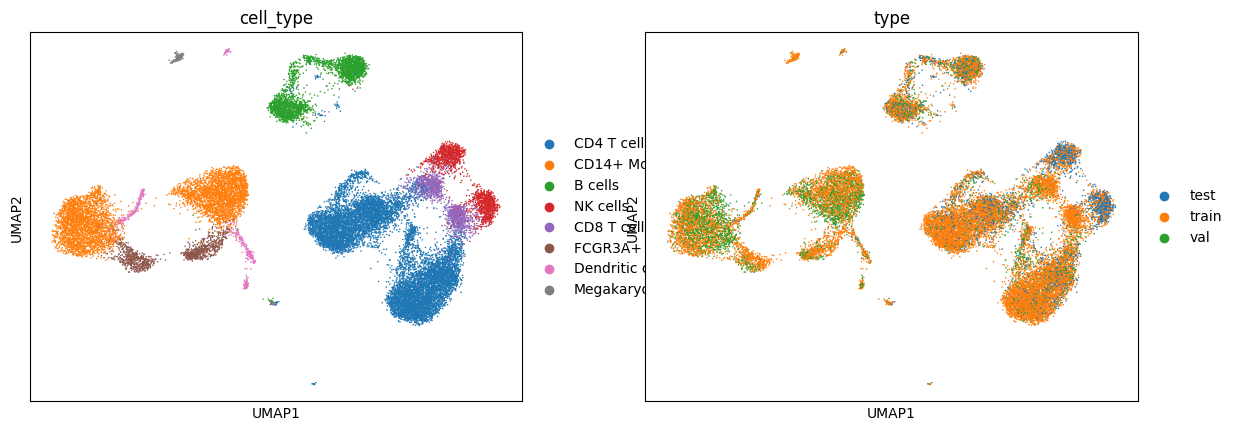

In [35]:
split = 'split03'

train_combinations = zarr.open_group(f'/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/{split}/split_metadata.zarr', mode='r').attrs["train_combinations"]
test_combinations = zarr.open_group(f'/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/{split}/split_metadata.zarr', mode='r').attrs["test_combinations"]

tmp_plot.obs["is_train"] = tmp_plot.obs.apply(lambda x: x.combination_key in train_combinations, axis=1)
tmp_plot.obs["is_test"] = tmp_plot.obs.apply(lambda x: x.combination_key in test_combinations, axis=1)
tmp_plot.obs["type"] = tmp_plot.obs.apply(lambda x: "test" if x.is_test else ("train" if x.is_train else "val"), axis=1)
sc.pl.umap(tmp_plot, color=["cell_type", "type"])